# 딥러닝 ② FOCUS ON TRANSFORMER


___
# 1. RNN의 한계와 어텐션의 등장
---

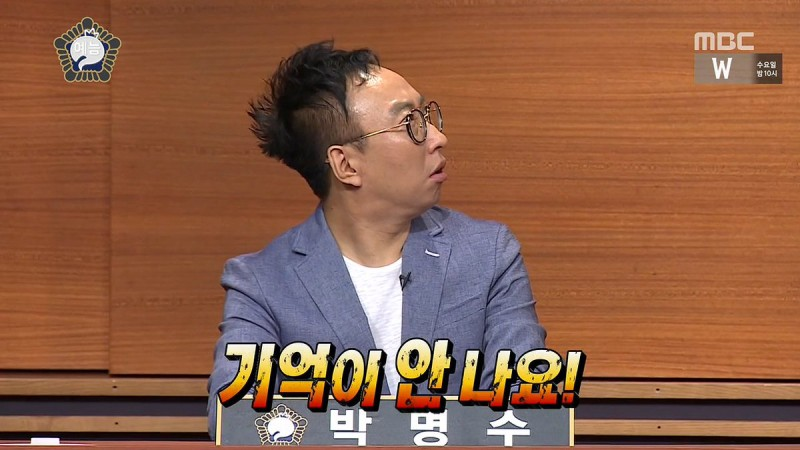

### RNN의 한계


저번시간에 배웠듯이 RNN은 장기 의존성 문제를 포함해서 많은 문제들이 있었습니다.
이러한 한계들을 극복하기 위해서 어텐션이 등장하였는데, 이번시간에는 이 어텐션에 대해 알아보겠습니다

---

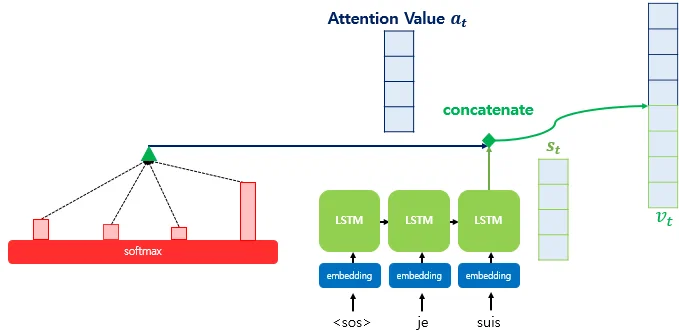

### 어텐션이란?
어텐션은 더 중요한 정보에 더 집중하는 메커니즘으로 결과를 만들떄 중요한 부분에 더 높은 가중치를 부여해 활용하는 것입니다.

장점 : 따라서 아무리 멀리 떨어진 단어라도 정보 손실 없이 파악해 RNN의 문제인 장기 의존성 문제를 해결할 수 있기에 등장했습니다.


### Attention is All You Need 

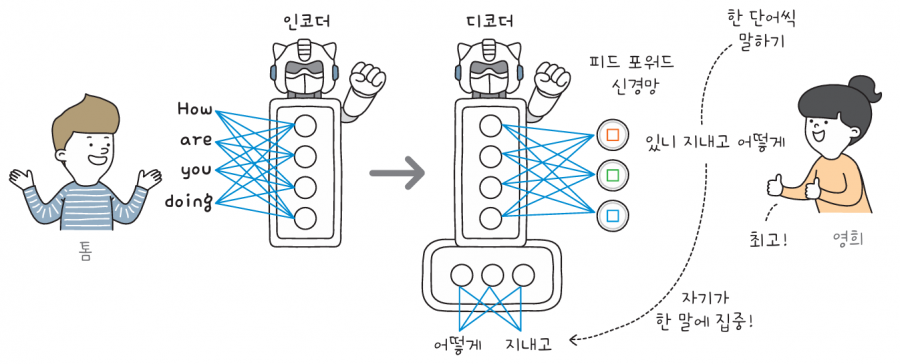

위처럼 RNN이 가진 한계와 문제점을 피하기 위해 오직 어텐션만을 사용하면 어떨까 라는 의문이 생겼고, 이에 따라 트랜스포머가 등장하였다.

트랜스포머는 병렬화가 가능해 모든 단어들을 동시에 계산할 수 있습니다.

이런 트랜스포머의 핵심 기술로는 총 세가지가 있는데 
- Self-Attention
- Multi-Head Attention
- Positional Encoding

이중 Self-Attention
과 Multi-Head Attention 두가지에 대해 집중적으로 알아보겠습니다.




---
# 2. Self-Attention
---

### Query, Key, Value

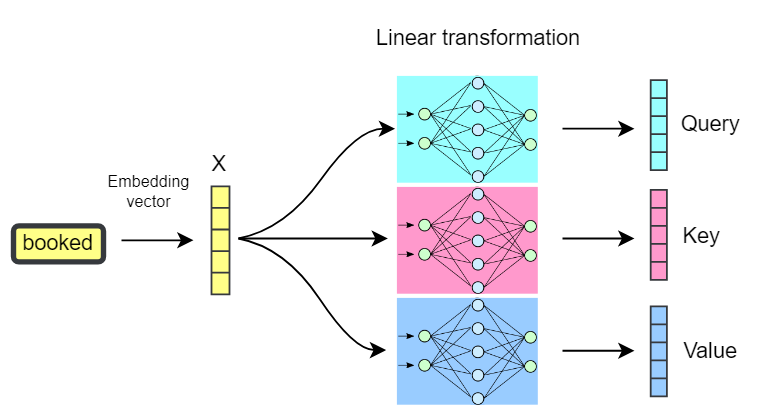


- Query
    - 쿼리는 사용자가 알고 싶거나 초점을 맞추고 있는 대상입니다.
- Key
    - 검색 대상이 되는 정보들이 달고 있는 이름표 라고 볼 수 있습니다.
- Value
    - 벨류는 키와 함께 묶여 있는 실제 내용물로 쿼리와 키의 계산이 끝나고 가장 관련있는 키가 선정되면 모델은 그 키에 해당된 벨류를 가져와 사용합니다.

예를 들어 투표를 한다고 가정해보겠습니다.

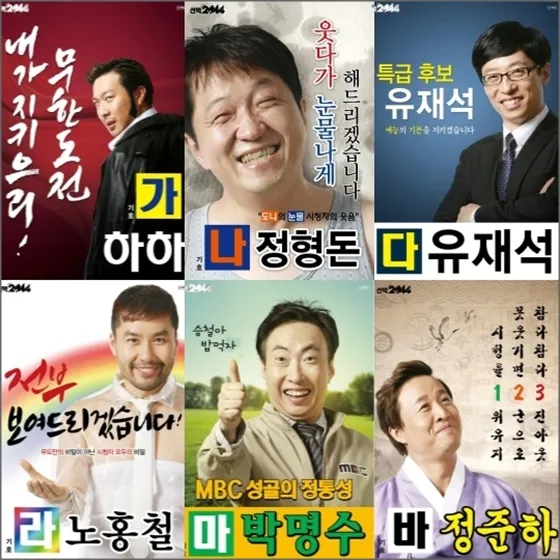

“무한도전을 안정적으로 진행할 사람 뽑아야 한다”

이 질문이 바로 Query(Q) 입니다.

각 후보가 가진 공약/이미지/특징이 Key(K)이며

예를 들면:

하하 → 예능감, 깐족

정형돈 → 드립, 센스

유재석 → 진행, 리더십

노홍철 → 텐션, 광기

박명수 → 호통, 독설

정준하 → 먹방, 어리버리

으로 두었을때

각 키를 비교해 가장 질문에 어울리는 걸 뽑습니다.

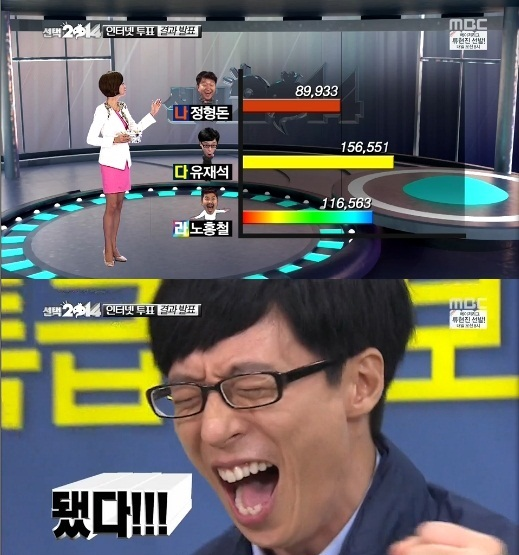

이때 유재석이 가장 가깝다고 판단을 했다면 유재석의 value를 가져오는것입니다.

---

### 기존 Cross-Attention vs. Self-Attention

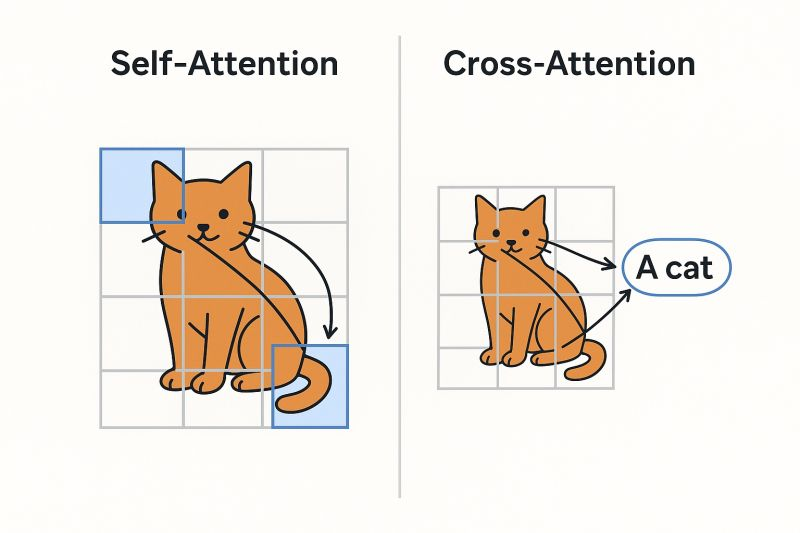

- 
    - Cross - Attention
    
    기존에는 하나의 시퀀스에서 다른 시퀀스를 참고해 정보를 만들어 냅니다. 즉 디코더가 인코다를 참고하는 정도로 사용했습니다
    
    - Self-Attention 
    
    문장 내부의 모든 내용을 살펴보는것으로 하나의 시퀀스 안에 모든 정보 각각의 연관성들을 분석합니다.

### Scaled Dot-Product Attention

Scaled Dot-Product Attention은 Query(Q)와 Key(K)의 내적값을 이용해 유사도를 계산한 뒤, 값이 너무 커지는 것을 방지하기 위해 Scaling을 적용한 Attention 방식입니다. 이를 통해 각 단어가 다른 단어를 얼마나 참고해야 하는지 계산합니다.

벡터 차원이 커질수록 내적값이 과도하게 커질 수 있으며, 이 값이 Softmax에 입력되면 특정 값에만 확률이 집중되어 학습이 불안정해질 수 있습니다. 따라서 값의 크기를 조절하여 보다 안정적으로 학습할 수 있도록 만듭니다.


---

## Multi-Head Attention

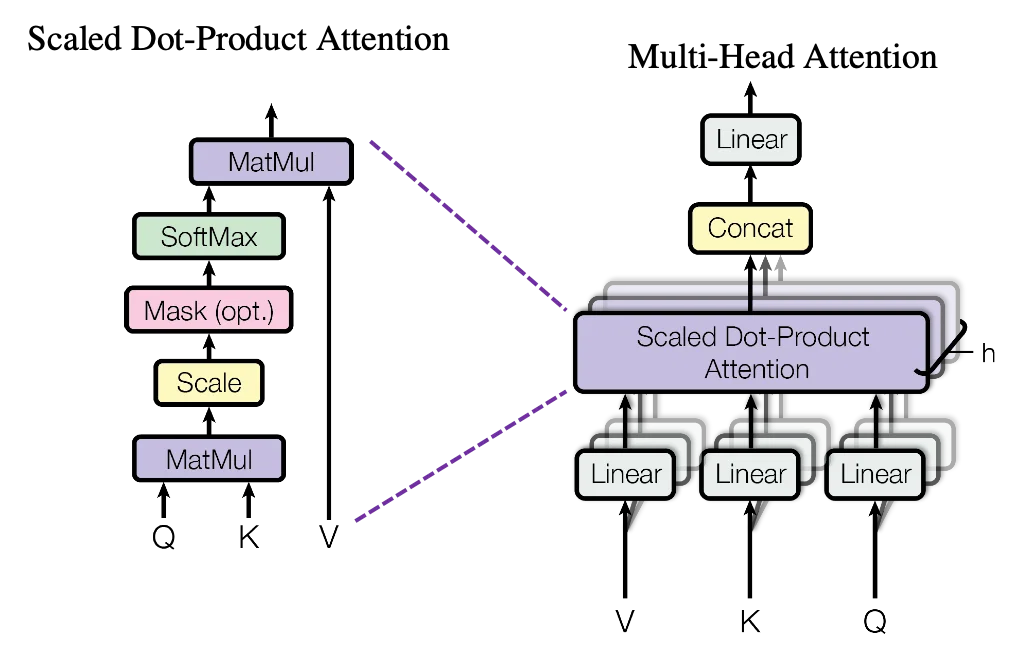

### Multi-Head Attention 이란?
Multi-Head Attention은 하나의 Attention만 사용하는 것이 아니라, 여러 개의 Attention을 동시에 수행하여 다양한 관계를 학습하는 방식입니다


### Multi-Head Attention 적동방식 

입력된 쿼리, 키, 벨류를 여러 개의 헤드로 분할한 뒤, 각 헤드에서 독립적으로 Scaled Dot-Product Attention을 수행합니다. 이후 각 헤드의 결과를 다시 합쳐 최종 출력 벡터를 생성합니다.

---


## Transformer 전체 아키텍처

### 트랜스포머의 전처리 단계  

트랜스포머는 입력 문장을 토큰 단위로 분할한 뒤, 각 토큰을 임베딩을 통해 숫자 벡터로 변환합니다. 이후 위치 인코딩을 추가하여 단어의 순서 정보를 함께 학습할 수 있도록 만듭니다.


### 트랜스포머의 Encoder와 Decoder  
 

인코더는 입력 문장의 전체 문맥과 의미를 이해하는 역할을 수행합니다. 셀프 어텐션과 피드 포워드 층을 반복하며 단어 간 관계를 학습하고, 문맥 정보를 담은 벡터를 생성합니다.

디코더는 인코더가 생성한 정보를 참고하여 출력 문장을 한 단어씩 생성합니다. 이 과정에서 마스크드 셀프 어텐션으로 이전 단어들만 참고하고, 크로스 어텐션을 통해 인코더의 입력 문장 정보를 함께 활용하여 다음 단어를 예측합니다.

---

